In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Load Peper Image and Plot It

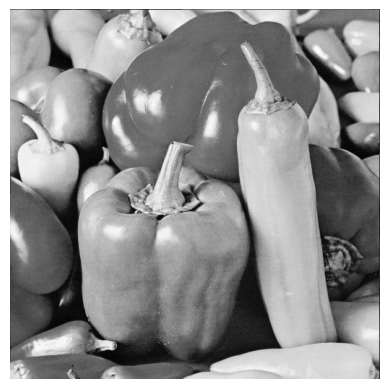

In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = sio.loadmat(work_path + 'Data/peppers.mat')['peppers']

# plot image
plt.imshow(img,cmap='gray')
plt.axis('off');

# Perform 2D-DWT on Peper Image

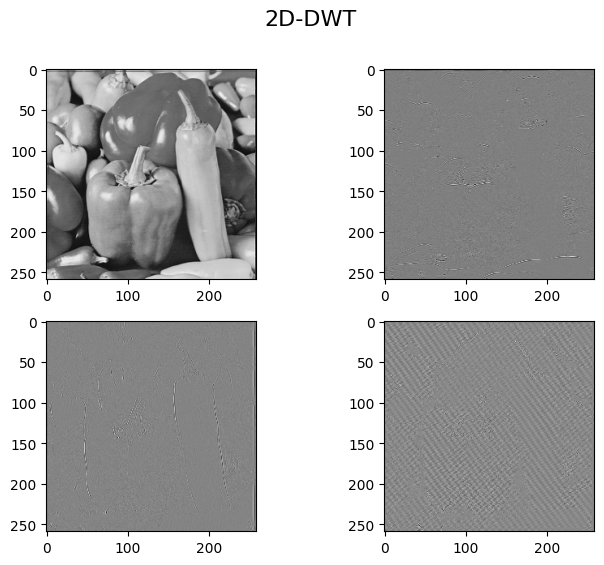

In [ ]:
import pywt

# take 2D-DWT
coeffs = pywt.dwt2(img, 'db4')
cA, (cH, cV, cD) = coeffs
coeffs_list = [cA, cH, cV, cD]

fig, ax = plt.subplots(2, 2, figsize=(8, 6))
fig.suptitle("2D-DWT", fontsize=16)
for i in range(2):
    for j in range(2):
        ax[i,j].imshow(coeffs_list[i*2+j], cmap='gray')
        # ax[i,j].axis('off')

# Perform Inverse 2D-DWT

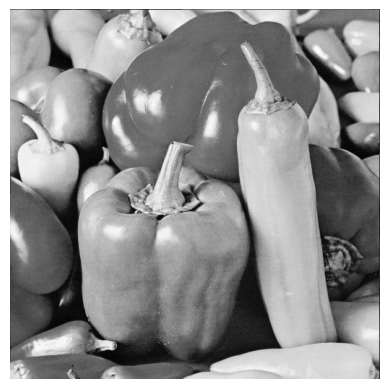

In [ ]:
# take 2D-iDCT
img_idwt = pywt.idwt2(coeffs, 'db4')

im = plt.imshow(img_idwt,cmap='gray')
plt.axis('off');

# Load Dog Image and Plot it

(np.float64(-0.5), np.float64(755.5), np.float64(1007.5), np.float64(-0.5))

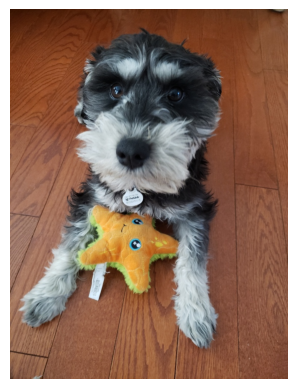

In [ ]:
from matplotlib import image
import numpy as np

# load image
img = image.imread(work_path + 'Data/Dog.jpg')
img = np.transpose(img, (0,1,2))

# plot image
import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')

# Perform 2D-DCT

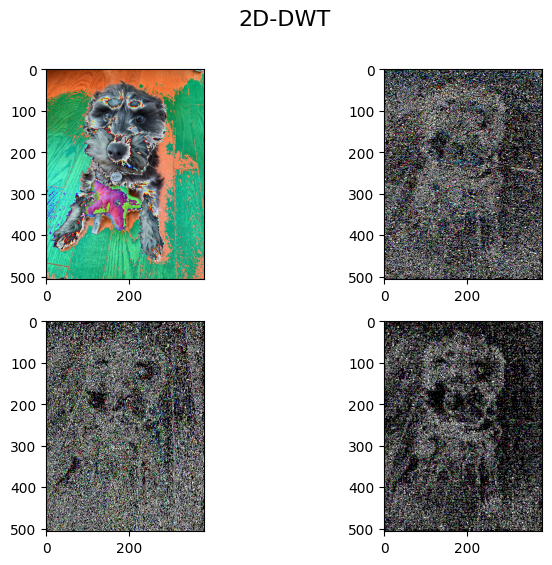

In [ ]:
import pywt
import cv2

# take 2D-DWT
coeffs = pywt.dwt2(img, 'db4',axes=(0,1))
cA, (cH, cV, cD) = coeffs
coeffs_list = [cA, cH, cV, cD]

fig, ax = plt.subplots(2, 2, figsize=(8, 6))
fig.suptitle("2D-DWT", fontsize=16)
for i in range(2):
    for j in range(2):
        norm_image = cv2.normalize(coeffs_list[i*2+j], None,
                                   alpha = coeffs_list[i*2+j].min(),
                                   beta = coeffs_list[i*2+j].max(),
                                   norm_type = cv2.NORM_MINMAX,
                                   dtype = cv2.CV_32F).astype(np.uint8)
        ax[i,j].imshow(norm_image)
        # ax[i,j].axis('off')



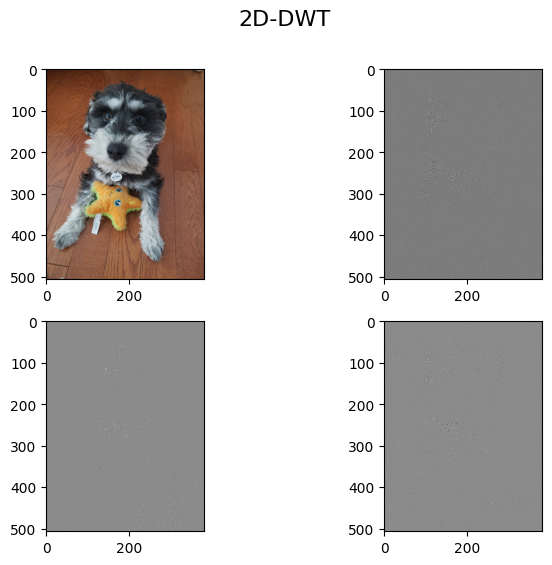

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
fig.suptitle("2D-DWT", fontsize=16)
for i in range(2):
    for j in range(2):
        norm_image = cv2.normalize(coeffs_list[i*2+j], None,
                                   alpha = 0,
                                   beta = 255,
                                   norm_type = cv2.NORM_MINMAX,
                                   dtype = cv2.CV_32F).astype('int')
        ax[i,j].imshow(norm_image)
        # ax[i,j].axis('off')

# Perform Inverse 2D-DCT

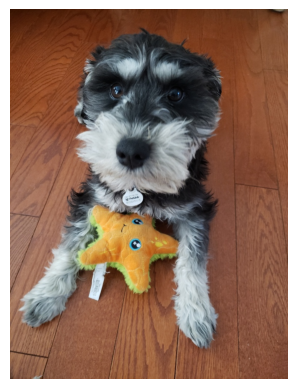

In [ ]:
# take 2D-iDWT
img_idwt = pywt.idwt2(coeffs, 'db4', axes=(0,1))

norm_image = cv2.normalize(img_idwt, None,
                           alpha = 0, beta = 255,
                           norm_type = cv2.NORM_MINMAX,
                           dtype = cv2.CV_32F).astype(np.uint8)
im = plt.imshow(norm_image)
plt.axis('off');


# Wavelet and Scaling Functions

Also refer to this link for MATLAB version: https://www.mathworks.com/help/wavelet/ref/dwtfilterbank.freqz.html

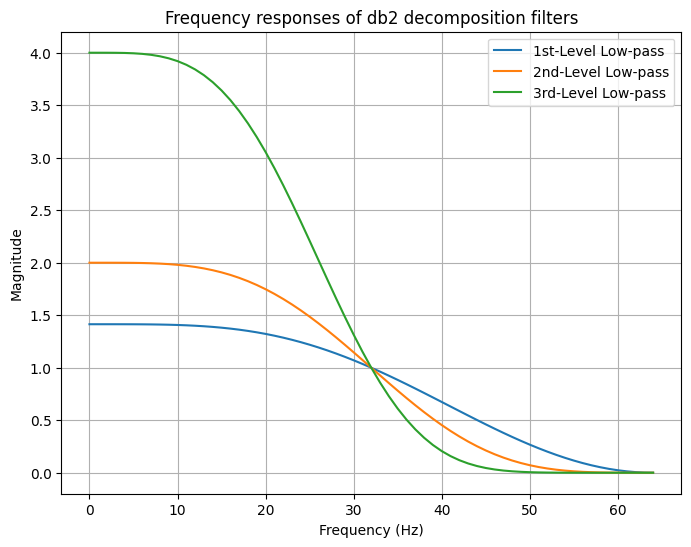

In [ ]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Create wavelet and extract the filters
wavelet_name = 'db2'
wavelet = pywt.Wavelet(wavelet_name)
dec_lo1, dec_hi1, rec_lo1, rec_hi1 = wavelet.filter_bank

# 2nd-level
dec_lo2 = signal.convolve(dec_lo1, dec_lo1)
# dec_hi2 = signal.convolve(dec_hi, dec_hi)

# 3rd level
dec_lo3 = signal.convolve(dec_lo2, dec_lo2)


# Frequency responses
dec_lo_fr1 = np.abs(np.fft.rfft(dec_lo1, 128))
# dec_hi_fr1 = np.abs(np.fft.rfft(dec_hi1, 128))
dec_lo_fr2 = np.abs(np.fft.rfft(dec_lo2, 128))
# dec_hi_fr2 = np.abs(np.fft.rfft(dec_hi2, 128))
dec_lo_fr3 = np.abs(np.fft.rfft(dec_lo3, 128))


plt.figure(figsize=(8, 6))
plt.plot(dec_lo_fr1, label='1st-Level Low-pass')
# plt.plot(dec_hi_fr1, label='1st-Level High-pass')
plt.plot(dec_lo_fr2, label='2nd-Level Low-pass')
# plt.plot(dec_hi_fr2, label='2st-Level High-pass')
plt.plot(dec_lo_fr3, label='3rd-Level Low-pass')


plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.legend()
plt.title('Frequency responses of {} decomposition filters'.format(wavelet_name))



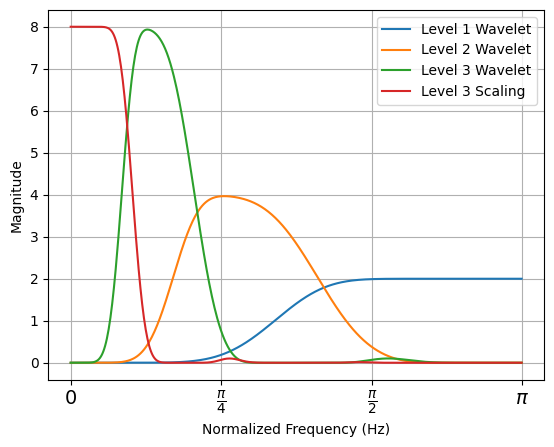

In [ ]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz
import math


'''
Note:
    phi: scaling function
    psi: wavelet function
    x: grid
'''

filtertype = 'db10'

# level-1 wavelet
[phi, psi, x] = pywt.Wavelet(filtertype).wavefun(level=1)
w, h = freqz(psi)
plt.plot(w, abs(h), label='Level 1 Wavelet')

# level-2 wavelet
[phi, psi, x] = pywt.Wavelet(filtertype).wavefun(level=2)
w, h = freqz(psi)
plt.plot(w, abs(h), label='Level 2 Wavelet')

# level-3 wavelet
[phi, psi, x] = pywt.Wavelet(filtertype).wavefun(level=3)
w, h = freqz(psi)
plt.plot(w, abs(h), label='Level 3 Wavelet')

w, h = freqz(phi)
plt.plot(w, abs(h), label='Level 3 Scaling')


# add figure details
xstick = np.linspace(0, math.pi, 4)
xstick_labels = [0, '$\\frac{\pi}{4}$', '$\\frac{\pi}{2}$', '$\pi$']

plt.xlabel('Normalized Frequency (Hz)')
# plt.xticks(ystick)
# plt.xticklabels(lam_beta, rotation='vertical')

plt.xticks(xstick, xstick_labels, fontsize=14)
plt.ylabel('Magnitude')
plt.grid(True)
plt.legend(loc='best')

List of available wavelets

In [ ]:
print(pywt.wavelist())

['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'haar', 'mexh', 'morl', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', 'shan', 'sym2', 'sym3